# Curating COVID example data


European Measles D8 sequences >14KB 2020-01-01 to 2024-12-31 from [Pathoplexus](https://pathoplexus.org/measles/search?dataUseTerms=OPEN&lengthFrom=14000&orderBy=sampleCollectionDate&order=ascending&sampleCollectionDateRangeLowerFrom=2020-01-01&genotype=D8&sampleCollectionDateRangeUpperTo=2024-12-31&geoLocCountry=Austria&geoLocCountry=France&geoLocCountry=Netherlands&geoLocCountry=Italy&geoLocCountry=Hungary) on 206-02-18.

In [9]:
import pandas as pd
from Bio import SeqIO
import matplotlib.pyplot as plt

In [2]:
metadata = pd.read_csv("measles_metadata_2026-02-18T2036.tsv", sep="\t", parse_dates=["sampleCollectionDate"])
metadata.head()

,accessionVersion,genotype,sampleCollectionDate,geoLocCountry,geoLocAdmin1,authors,authorAffiliations,hostNameScientific,length,earliestReleaseDate,...,biosampleAccession,completeness,geoLocAdmin2,geoLocCity,insdcAccessionFull,insdcRawReadsAccession,isLabHost,specimenCollectorSampleId,totalAmbiguousNucs,totalUnknownNucs
0,PP_003QESH.2,D8,2023-07-10,Hungary,NaN,"Deezsi-Magyar, N.; Tarcsai, K. R.; Zsidei, G.;...",National Center for Public Health and Pharmacy...,Homo sapiens,15896,2024-06-12,...,NaN,0.999937,NaN,NaN,PP887450.1,NaN,NaN,MVs/Szeged.HUN/27.23[D8],1,0
1,PP_003QGMR.2,D8,2024-03-22,Hungary,NaN,"Deezsi-Magyar, N.; Tarcsai, K. R.; Zsidei, G.;...",National Center for Public Health and Pharmacy...,Homo sapiens,15878,2024-08-03,...,NaN,0.998175,NaN,NaN,PP998305.1,NaN,NaN,MVs/Melykut.HUN/12.24[D8],1,12
2,PP_003QGNP.2,D8,2024-05-09,Hungary,NaN,"Deezsi-Magyar, N.; Tarcsai, K. R.; Zsidei, G.;...",National Center for Public Health and Pharmacy...,Homo sapiens,15894,2024-08-03,...,NaN,0.998301,NaN,NaN,PP998306.1,NaN,NaN,MVs/Kunfeherto.HUN/19.23[D8],12,15
3,PP_003QGPM.2,D8,2024-05-14,Hungary,NaN,"Deezsi-Magyar, N.; Tarcsai, K. R.; Zsidei, G.;...",National Center for Public Health and Pharmacy...,Homo sapiens,15895,2024-08-03,...,NaN,1.000000,NaN,NaN,PP998307.1,NaN,NaN,MVs/Melykut.HUN/19.24[D8],0,0
4,PP_003QGQK.2,D8,2024-05-24,Hungary,NaN,"Deezsi-Magyar, N.; Tarcsai, K. R.; Zsidei, G.;...",National Center for Public Health and Pharmacy...,Homo sapiens,15894,2024-08-03,...,NaN,1.000000,NaN,NaN,PP998308.1,NaN,NaN,MVs/Hetenyegyhaza/19.24[D8],0,0


In [3]:
metadata["sampleCollectionDate"].value_counts(dropna=False)

sampleCollectionDate
2024-02-11    8
2024-02-29    6
2024-02-04    6
2024-02-13    5
2024-02-18    5
             ..
2024-07-02    1
2024-07-16    1
2024-08-16    1
2024-10-04    1
2024-10-15    1
Name: count, Length: 116, dtype: int64

In [4]:
def safe_date_parser(x):
    return pd.to_datetime(x, errors='coerce', format="%Y-%m-%d")
metadata["sampleCollectionDate"] = metadata["sampleCollectionDate"].apply(safe_date_parser)
metadata["sampleCollectionDate"].value_counts(dropna=False)

sampleCollectionDate
2024-02-11    8
2024-02-29    6
2024-02-04    6
2024-02-13    5
2024-02-18    5
             ..
2024-07-02    1
2024-07-16    1
2024-08-16    1
2024-10-04    1
2024-10-15    1
Name: count, Length: 116, dtype: int64

In [5]:
metadata = metadata.dropna(subset=["sampleCollectionDate"])
metadata["sampleCollectionDate"].value_counts(dropna=False)
metadata.to_csv("all_measles_metadata.tsv", sep="\t", index=False)
valid_ids = metadata['accessionVersion'].tolist()


<Axes: >

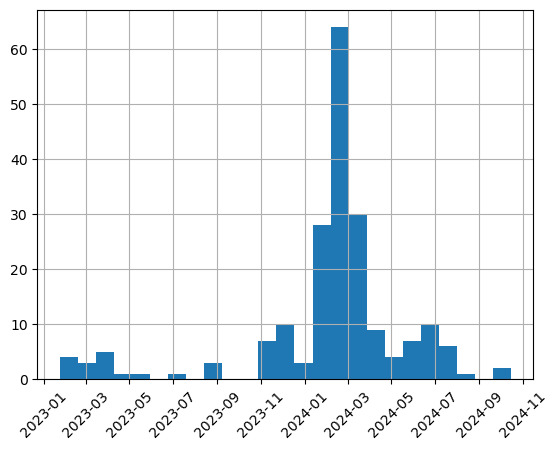

In [12]:
plt.xticks(rotation=45)
metadata["sampleCollectionDate"].hist(bins=25)

In [7]:
metadata['geoLocCountry'].value_counts()

geoLocCountry
Austria        127
Netherlands     52
Italy           14
Hungary          5
France           1
Name: count, dtype: int64

In [14]:
metadata_Netherlands = metadata[metadata['geoLocCountry'] == "Netherlands"]
metadata_Netherlands
metadata_Netherlands.to_csv('Netherlands_measles_metadata.csv', index=False)

,accessionVersion,genotype,sampleCollectionDate,geoLocCountry,geoLocAdmin1,authors,authorAffiliations,hostNameScientific,length,earliestReleaseDate,...,biosampleAccession,completeness,geoLocAdmin2,geoLocCity,insdcAccessionFull,insdcRawReadsAccession,isLabHost,specimenCollectorSampleId,totalAmbiguousNucs,totalUnknownNucs
147,PP_004FFJG.1,D8,2024-02-07,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.994904,NaN,NaN,PX614698.1,NaN,NaN,MVs/Limburg.NLD/6.24[D8],0,0
148,PP_004FFKE.1,D8,2024-02-11,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.994715,NaN,NaN,PX614699.1,NaN,NaN,MVs/Limburg.NLD/6.24/2[D8],0,3
149,PP_004FFLC.1,D8,2024-02-15,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985340,NaN,NaN,PX614700.1,NaN,NaN,MVs/Noord-Brabant.NLD/7.24[D8],0,152
150,PP_004FFMA.1,D8,2024-02-28,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985340,NaN,NaN,PX614701.1,NaN,NaN,MVs/Noord-Brabant.NLD/8.24[D8],0,152
151,PP_004FFN8.1,D8,2024-02-29,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985277,NaN,NaN,PX614702.1,NaN,NaN,MVs/Noord-Brabant.NLD/9.24[D8],1,152
152,PP_004FFP6.1,D8,2024-03-07,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985340,NaN,NaN,PX614703.1,NaN,NaN,MVs/Noord-Brabant.NLD/9.24/2[D8],0,152
153,PP_004FFQ4.1,D8,2024-03-11,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985277,NaN,NaN,PX614704.1,NaN,NaN,MVs/Noord-Brabant.NLD/10.24[D8],1,152
154,PP_004FFR2.1,D8,2024-03-11,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985277,NaN,NaN,PX614705.1,NaN,NaN,MVs/Noord-Brabant.NLD/10.24/2[D8],1,152
155,PP_004FFS0.1,D8,2024-03-13,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.985340,NaN,NaN,PX614706.1,NaN,NaN,MVs/Noord-Brabant.NLD/11.24[D8],0,152
156,PP_004FFTY.1,D8,2024-03-23,Netherlands,NaN,"Maissan, C.; van de Nes-Reijnen, L.; Zwagemake...",National Institute for Public Health and the E...,Homo sapiens,15813,2025-12-27,...,NaN,0.984900,NaN,NaN,PX614707.1,NaN,NaN,MVs/Noord-Brabant.NLD/12.24/3[D8],7,152


In [13]:
metadata_Vienna = metadata[metadata['geoLocAdmin1'].isin(["Vienna",'Vienna,Vienna'])]
metadata_Vienna

,accessionVersion,genotype,sampleCollectionDate,geoLocCountry,geoLocAdmin1,authors,authorAffiliations,hostNameScientific,length,earliestReleaseDate,...,biosampleAccession,completeness,geoLocAdmin2,geoLocCity,insdcAccessionFull,insdcRawReadsAccession,isLabHost,specimenCollectorSampleId,totalAmbiguousNucs,totalUnknownNucs
18,PP_003QJSD.2,D8,2023-11-10,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786147.1,NaN,NaN,MVs/Wien.AUT/45.23[D8],0,0
19,PP_003QJTB.2,D8,2023-11-08,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786148.1,NaN,NaN,MVs/Wien.AUT/45.23/2[D8],0,0
20,PP_003QJU9.2,D8,2023-11-11,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786149.1,NaN,NaN,MVs/Wien.AUT/45.23/3[D8],0,0
21,PP_003QJV7.2,D8,2023-11-16,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786150.1,NaN,NaN,MVs/Wien.AUT/46.23[D8],0,0
22,PP_003QJW5.2,D8,2023-11-18,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786151.1,NaN,NaN,MVs/Wien.AUT/46.23/2[D8],0,0
23,PP_003QJX3.2,D8,2023-12-08,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786152.1,NaN,NaN,MVs/Wien.AUT/49.23/3[D8],0,0
24,PP_003QJY1.2,D8,2023-12-14,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786153.1,NaN,NaN,MVs/Wien.AUT/50.23/5[D8],0,0
25,PP_003QJZZ.2,D8,2023-12-20,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786154.1,NaN,NaN,MVs/Wien.AUT/51.23[D8],0,0
26,PP_003QK0X.2,D8,2024-01-13,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786155.1,NaN,NaN,MVs/Wien.AUT/02.24/2[D8],0,0
27,PP_003QK1V.2,D8,2024-01-26,Austria,Vienna,"Aberle, S. W.; Weseslindtner, L.","Medical University of Vienna, Center for Virology",Homo sapiens,15697,2025-01-08,...,NaN,0.987605,NaN,NaN,PQ786156.1,NaN,NaN,MVs/Wien.AUT/04.24[D8],0,0


In [8]:
with open("all_measles.fasta", "w") as all_file:
    with open("all_measles_metadata.tsv", "w") as metadata_file:

    for sequence in SeqIO.parse("measles_aligned-nuc_2026-02-18T2036.fasta", "fasta"):
        if sequence.id in valid_ids:
            SeqIO.write(sequence, all_file, "fasta")

all_file.close()